In [1]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/ImageDataset"

Mounted at /content/drive


In [2]:
import tensorflow as tf
img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

class_names = train_ds.class_names

Found 5455 files belonging to 20 classes.
Using 4364 files for training.
Found 5455 files belonging to 20 classes.
Using 1091 files for validation.


In [3]:
from tensorflow.keras import layers, models

def build_model(base_model):
  base_model.trainable = False # Transfer Learning

  model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names))
])

  return model

In [4]:
from tensorflow.keras.applications import MobileNetV2, EfficientNetB3, NASNetMobile

models_dict = {
    "MobileNetV2": MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "EfficientNetB3": EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224,224,3)),
    "NASNetMobile": NASNetMobile(weights='imagenet', include_top=False, input_shape=(224,224,3))
}

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
from tensorflow.keras.optimizers import Adam

histories = {}
trained_models = {}

for name, base in models_dict.items():
    print(f"Training {name}...")
    model = build_model(base)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    history = model.fit(        # ← make sure this is indented
        train_ds,               # ← inside the for loop
        validation_data=val_ds,
        epochs=13
    )
    histories[name] = history   # ← same here
    trained_models[name] = model # ← and here

Training MobileNetV2...
Epoch 1/13


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 844s 6s/step - accuracy: 0.1489 - loss: 2.8782 - val_accuracy: 0.4510 - val_loss: 2.3170
Epoch 2/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.3760 - loss: 2.1605 - val_accuracy: 0.6279 - val_loss: 1.6854
Epoch 3/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.5156 - loss: 1.6908 - val_accuracy: 0.7232 - val_loss: 1.2842
Epoch 4/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.6013 - loss: 1.3882 - val_accuracy: 0.7773 - val_loss: 1.0525
Epoch 5/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.6643 - loss: 1.1887 - val_accuracy: 0.7993 - val_loss: 0.8978
Epoch 6/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.6890 - loss: 1.0770 - val_accuracy: 0.8194 - val_loss: 0.8068
Epoch 7/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.7303 - loss: 0.9443 - val_accuracy: 0.8203 - val_loss: 0.7296
Epoch 8/13
137/137 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.7516 - loss: 0.8668 - val_accuracy: 0.837

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
def evaluate_model(model):

  y_true, y_pred = [], []
  for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.argmax(axis=1))
  print(classification_report(y_true, y_pred))
  return y_true, y_pred

In [7]:
import matplotlib.pyplot as plt
import numpy as np
def plot_confusion_matrix(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.imshow(cm)
  plt.title(title)
  plt.colorbar()
  plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
  plt.yticks(np.arange(len(class_names)), class_names)
  for i in range(len(class_names)):
     for j in range(len(class_names)):
       plt.text(j, i, cm[i, j], ha='center')
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.show()

In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
def plot_roc(model):
  y_true, y_prob = [], []
  for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_prob.extend(preds)

  y_true = np.array(y_true)
  y_prob = np.array(y_prob)

  y_bin = label_binarize(y_true, classes=range(len(class_names)))
  for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr)
  plt.title("ROC Curve")
  plt.show()

In [13]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my_image_classifier.keras")
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (32, 180, 180, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 180, 180, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 90, 90, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 90, 90, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 45, 45, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 45, 45, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 22, 22, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 30976)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 128)              │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (32, 128)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 20)               │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,973,662 (45.68 MB)

 Trainable params: 3,991,220 (15.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,982,442 (30.45 MB)

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
img_path = "/content/drive/MyDrive/test_image.jpg"
img = load_img(img_path, target_size=(180, 180))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

In [15]:
for layer in model.layers:
  print(layer.name)
last_conv_layer_name = "conv2d_8" # Adjust based on your model

sequential_1
rescaling_2
conv2d_6
max_pooling2d_6
conv2d_7
max_pooling2d_7
conv2d_8
max_pooling2d_8
dropout_2
flatten_2
dense_4
dropout_3
dense_5


In [16]:
import tensorflow as tf
import numpy as np

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # Warm up the full model
    _ = model(img_array, training=False)

    # Build a sub-model that SKIPS sequential_2 (augmentation)
    # Start from rescaling_1 (index 1) directly
    input_tensor = tf.keras.Input(shape=(180, 180, 3))
    x = input_tensor

    reached_target = False
    conv_output_tensor = None

    for layer in model.layers[1:]:
        x = layer(x, training=False)
        if layer.name == last_conv_layer_name:
            conv_output_tensor = x
            reached_target = True

    grad_model = tf.keras.Model(
        inputs=input_tensor,
        outputs=[conv_output_tensor, x]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        tape.watch(conv_outputs)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

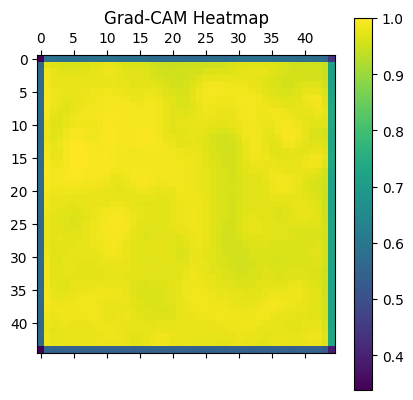

In [17]:
heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)
import matplotlib.pyplot as plt
plt.matshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()


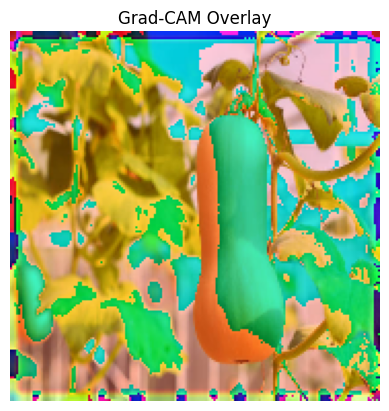

In [18]:
import cv2
img = cv2.imread(img_path)
img = cv2.resize(img, (180, 180))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = heatmap * 0.4 + img
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [19]:
for name, model in trained_models.items():
    model.save(f"/content/drive/MyDrive/{name}_model.keras")
    print(f"✅ Saved: {name}")

✅ Saved: MobileNetV2
✅ Saved: EfficientNetB3
✅ Saved: NASNetMobile
